<a href="https://colab.research.google.com/github/romavallejo/TC3009C.600_AIClass/blob/main/%20/P2M1Statistics4dataScience2/RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# INSTRUCCIONES
# - ajuste una regresion lineal para predicr O3 usando NO, NO2, NOX y CO y reporte R^2, coeficientes y sus p-values
# - calcule el VIF de cada variables
# - grafique residuos vs predichos y corra Preush_pagan
# - grafique los residuos en el tiempo y su promedio por hora del día, calcule durbin-Watson
# - Haga el QQ-plot de los residuos
# - ¿qué supuestos se rompen? ¿creen al coeficinete del NO2 y su p-value?

In [17]:
# INSTALAR EL DATA SET
import pandas as pd

df = pd.read_csv("contaminantes_2026.csv", skiprows=9)
print(df.head())
print(df["id_station"].unique())
df["id_parameter"].unique()

                  date id_station id_parameter  valor  unit
0  2026-01-01 00:00:00        ACO           CO    NaN    15
1  2026-01-01 00:00:00        ACO           NO    NaN     1
2  2026-01-01 00:00:00        ACO          NO2    NaN     1
3  2026-01-01 00:00:00        ACO          NOX    NaN     1
4  2026-01-01 00:00:00        ACO           O3    NaN     1
['ACO' 'AJM' 'AJU' 'ATI' 'BJU' 'CAM' 'CCA' 'CHO' 'CUA' 'CUT' 'FAC' 'FAR'
 'GAM' 'HGM' 'INN' 'IZT' 'LLA' 'LPR' 'MER' 'MGH' 'MON' 'MPA' 'NEZ' 'PED'
 'SAC' 'SAG' 'SFE' 'TAH' 'TLA' 'TLI' 'UAX' 'UIZ' 'VIF' 'XAL']


array(['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PMCO', 'SO2'],
      dtype=object)

In [10]:
# MINI LIMPIEZA DE DATOS RESCATADA DE NOTEBOOK ANTERIOR
# Revisar si hay valores nulos
df.isnull().sum()

# Limpieza de nulos
df["valor"] = pd.to_numeric(df["valor"].fillna(0), errors="coerce")
df["unit"] = df["unit"].fillna("N/A")

df.isnull().sum()

# date a datetime
df["date"] = pd.to_datetime(df["date"], format="mixed")

In [29]:
# SELECCIÓN DE ESTACIÓN PARA ENTRENAMIENTO DE LA REGRESIÓN LINEAL
# en mi caso escogí la estación -> ACO
# - ajuste una regresion lineal para predicr O3 usando NO, NO2, NOX y CO y reporte R^2, coeficientes y sus p-values

processed_df = df[df["id_station"] == "ACO"]

processed_df = processed_df.pivot_table(
    index="date",
    columns="id_parameter",
    values="valor",
    aggfunc="mean",
    dropna=False
).reset_index()

processed_df.columns.name = None
print(processed_df.columns.tolist())
processed_df.head()

cols_modelo = ["O3", "NO", "NO2", "NOX", "CO"]
regresion_df = processed_df[["date"] + cols_modelo]
regresion_df = regresion_df.dropna(subset=cols_modelo)
print(regresion_df.shape)
regresion_df.head()

['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PMCO', 'SO2']
(3627, 6)


,date,O3,NO,NO2,NOX,CO
312,2026-01-14 00:00:00,22.0,1.0,14.0,15.0,0.13
313,2026-01-14 01:00:00,22.0,1.0,12.0,13.0,0.12
314,2026-01-14 02:00:00,15.0,1.0,17.0,18.0,0.12
315,2026-01-14 03:00:00,13.0,1.0,17.0,18.0,0.12
316,2026-01-14 04:00:00,6.0,3.0,19.0,22.0,0.17


In [33]:
# ENTRENAMIENTO, R^2 y P-values
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = regresion_df[["NO", "NO2", "NOX", "CO"]]
y = regresion_df["O3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Coeficientes:", dict(zip(X.columns, modelo.coef_)))
print("Intercepto:", modelo.intercept_)
print("R^2 (test):", r2_score(y_test, y_pred))

Coeficientes: {'NO': np.float64(-0.26444753836302765), 'NO2': np.float64(-1.344682011720697), 'NOX': np.float64(-0.6848072878290707), 'CO': np.float64(44.321101914264)}
Intercepto: 58.94053745137602
R^2 (test): 0.4504689968380873


In [34]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
modelo_sm = sm.OLS(y_train, X_train_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                     O3   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     523.9
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:20:01   Log-Likelihood:                -12751.
No. Observations:                2901   AIC:                         2.551e+04
Df Residuals:                    2896   BIC:                         2.554e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.9405      0.812     72.566      0.0

In [35]:
# CÁLCULO DE VIF (multicolinealidad)

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train)
vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_df)

  variable          VIF
0    const     1.000000
1       NO   425.631983
2      NO2   310.993141
3      NOX  1059.092948
4       CO     3.099167


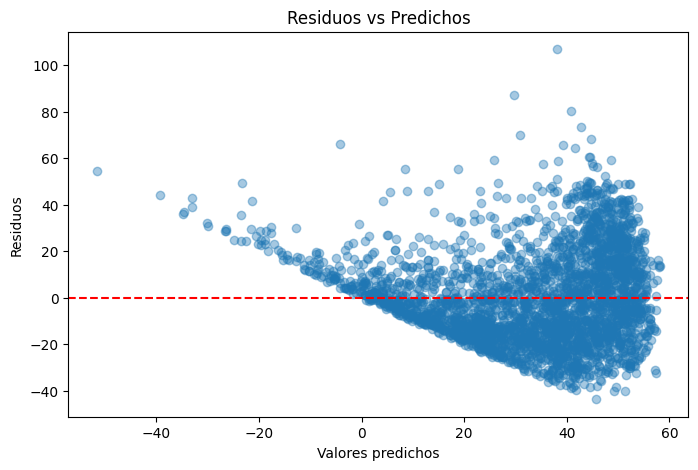

{'LM stat': np.float64(64.58862702362127), 'LM p-value': np.float64(3.141433781786954e-13), 'F stat': np.float64(16.48638360804201), 'F p-value': np.float64(2.3033496592288835e-13)}


In [36]:
# RESIDUOS VS PREDICHOS, PREUSH-PAGAN
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan

residuos = modelo_sm.resid
predichos = modelo_sm.fittedvalues

plt.figure(figsize=(8,5))
plt.scatter(predichos, residuos, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Predichos")
plt.show()

bp_test = het_breuschpagan(residuos, X_train_sm)
labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print(dict(zip(labels, bp_test)))

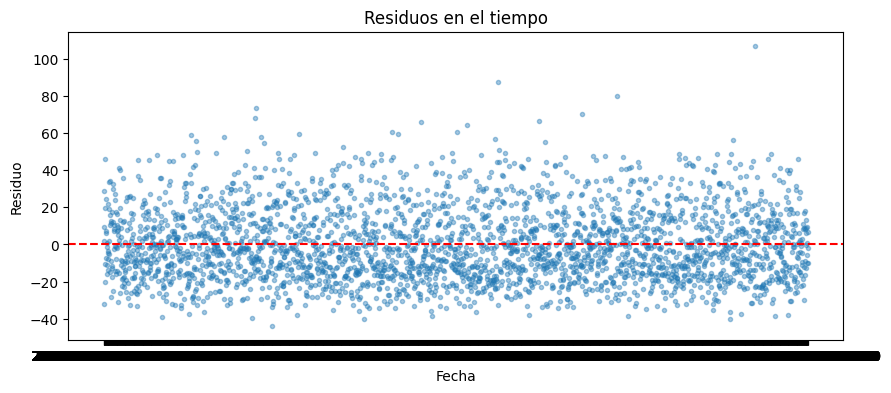

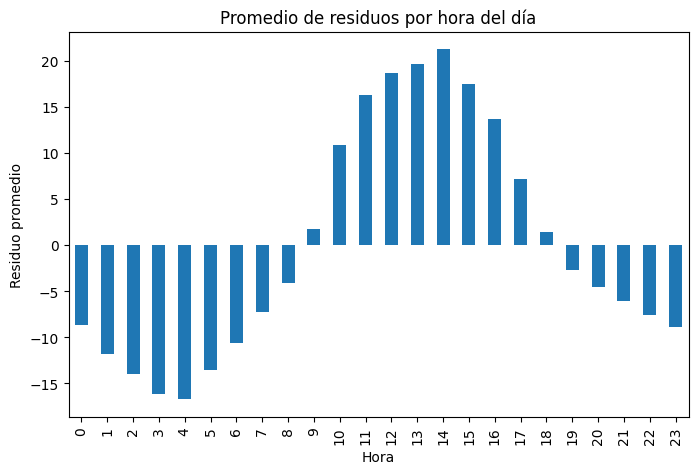

Durbin-Watson: 2.0230976696301335


In [39]:
# RESIDUOS EN EL TIEMPO Y PROMEDIO POR HORA DEL DIA, DURBIN-WATSON
# - grafique los residuos en el tiempo y su promedio por hora del día, calcule durbin-Watson
from statsmodels.stats.stattools import durbin_watson

fechas_train = regresion_df.loc[X_train.index, "date"]

plt.figure(figsize=(10,4))
plt.plot(fechas_train, residuos, marker=".", linestyle="none", alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Residuo")
plt.show()

fechas_train = pd.to_datetime(regresion_df.loc[X_train.index, "date"])
residuos_por_hora = residuos.groupby(fechas_train.dt.hour).mean()
plt.figure(figsize=(8,5))
residuos_por_hora.plot(kind="bar")
plt.title("Promedio de residuos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Residuo promedio")
plt.show()

print("Durbin-Watson:", durbin_watson(residuos))

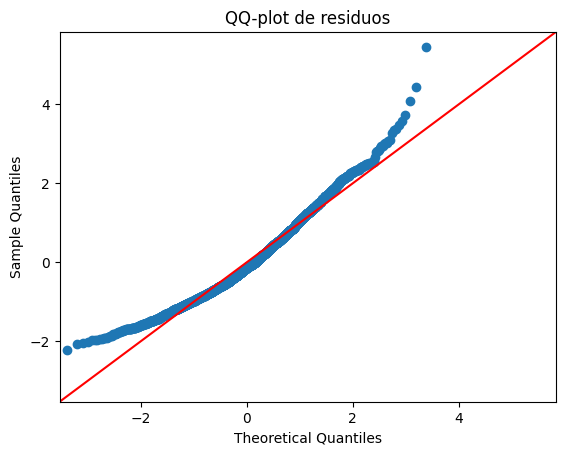

In [38]:
# QQPLOT
import statsmodels.api as sm

sm.qqplot(residuos, line="45", fit=True)
plt.title("QQ-plot de residuos")
plt.show()

## ¿Qué supuestos se rompen?

**Homocedasticidad -> se rompe:** El test de Breusch-Pagan da un p-value de muy por debajo de 0.05, así que rechazamos la hipótesis. Esto es consistente con lo que se ve en la gráfica de residuos vs predichos, donde la dispersión no es pareja a lo largo del eje x.

**Independencia de los errores -> no se rompe:** El estadístico de Durbin-Watson es 2.023, prácticamente el valor ideal (2.0 indica ausencia de autocorrelación).

**Normalidad de los residuos -> se rompe:** El QQ-plot muestra colas que se desvían claramente de la línea de 45°, sobre todo en el extremo superior, y el test de Jarque-Bera del summary confirma que los residuos no siguen una distribución normal. El skew de 0.669 indica una cola derecha más pesada, es decir, hay más valores atípicos de O3 sobreestimados o subestimados en una dirección que en otra.

**Multicolinealidad -> se rompe, y de forma severa:** Los VIF de NO (425.6), NO2 (311.0) y NOX (1059.1) están muy por encima Eto es esperable: NOX es prácticamente la suma de NO y NO2 por definición química, así que las tres variables están capturando casi la misma información. CO, en cambio, tiene un VIF de 3.1, que está en un rango razonable.

## ¿Le creemos al coeficiente de NO2 y su p-value?

No mucho. El VIF de NO2 es altísimo, así que el modelo no logra separar bien su efecto del de NO y NOX — eso infla el error estándar y probablemente por eso el p-value (0.078) queda justo en el límite sin ser claramente significativo. Además, como tampoco hay homocedasticidad, ese p-value está calculado bajo un supuesto que ya sabemos que no se cumple.

En resumen: el coeficiente de NO2 no es confiable tal como está, no porque NO2 no importe, sino porque el modelo no puede aislar su efecto de NOX. Antes de confiar en él habría que quitar NOX (es redundante) o usar algo como ridge regression para lidiar con la colinealidad.